In [2]:
!pip install scikit-learn


In [1]:
!pip install scikit-learn


In [2]:
import sys
!{sys.executable} -m pip install scikit-learn


  Using cached scikit_learn-1.8.0-cp314-cp314-win_amd64.whl.metadata (11 kB)
  Using cached scipy-1.17.0-cp314-cp314-win_amd64.whl.metadata (60 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.1 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.1 MB ? eta -:--:--
   -- ------------------------------------- 0.5/8.1 MB 812.8 kB/s eta 0:00:10
   --- ------------------------------------ 0.8/8.1 MB 862.7 kB/s eta 0:00:09
   --- ------------------------------------ 0.8/8.1 MB 862.7 kB/s eta 0:00:09
   --- ------------------------------------ 0.8/8.1 MB 862.7 kB/s eta 0:00:09
   --- ------------------------------------ 0.8/8.1 MB 862.7 kB/s eta 0:00:09
   --- ------------------------------------ 0.8/8.1 MB


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: C:\Users\rohit\AppData\Local\Python\pythoncore-3.14-64\python.exe -m pip install --upgrade pip


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, accuracy_score


In [5]:
df = pd.read_csv(r"C:\Users\rohit\Downloads\german_credit_data.csv")

print(df.head())
print(df.info())

   Unnamed: 0  Age     Sex  Job Housing Saving accounts Checking account  \
0           0   67    male    2     own             NaN           little   
1           1   22  female    2     own          little         moderate   
2           2   49    male    1     own          little              NaN   
3           3   45    male    2    free          little           little   
4           4   53    male    2    free          little           little   

   Credit amount  Duration              Purpose  
0           1169         6             radio/TV  
1           5951        48             radio/TV  
2           2096        12            education  
3           7882        42  furniture/equipment  
4           4870        24                  car  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Unnamed: 0        1000 non-null   int64 

In [6]:
df.drop(columns=["Unnamed: 0"], inplace=True)


In [7]:
df["Saving accounts"].fillna("unknown", inplace=True)
df["Checking account"].fillna("unknown", inplace=True)


In [8]:
df["Risk"] = pd.cut(
    df["Credit amount"],
    bins=[0, 3000, 7000, np.inf],
    labels=["Low", "Medium", "High"]
)


In [9]:
le = LabelEncoder()

for col in df.select_dtypes(include="object").columns:
    df[col] = le.fit_transform(df[col])


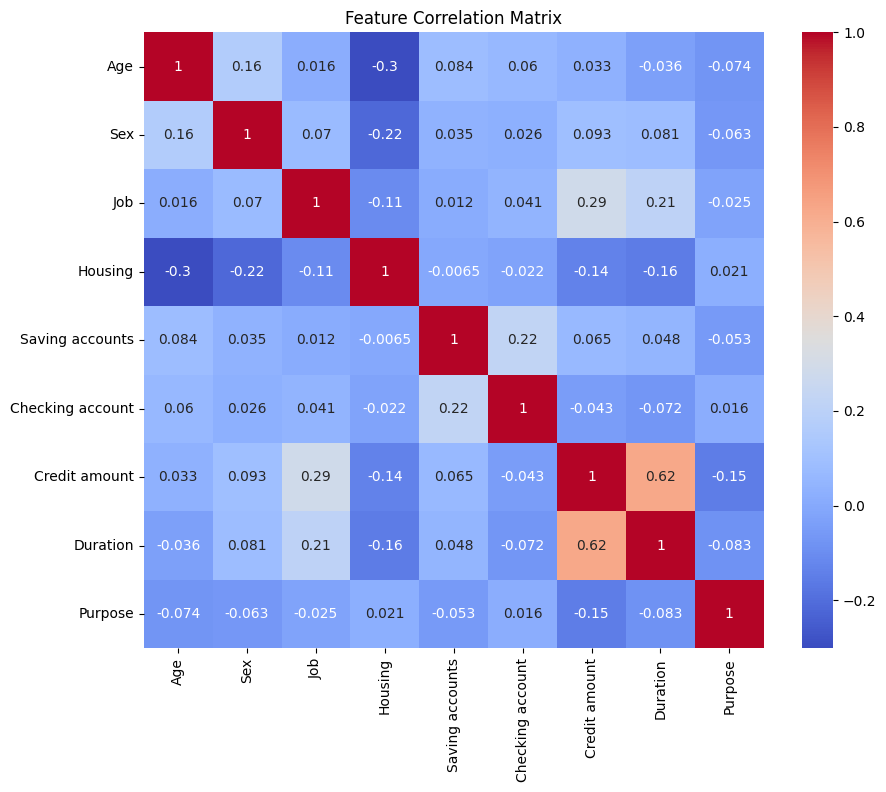

In [12]:
numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(10,8))
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm")
plt.title("Feature Correlation Matrix")
plt.show()


In [13]:
X = df.drop("Risk", axis=1)
y = df["Risk"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [14]:
dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))


Decision Tree Accuracy: 1.0


In [15]:
rf = RandomForestClassifier()
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))


Random Forest Accuracy: 1.0


In [16]:
gb = GradientBoostingClassifier()
gb.fit(X_train, y_train)

y_pred_gb = gb.predict(X_test)
print("Boosting Accuracy:", accuracy_score(y_test, y_pred_gb))


Boosting Accuracy: 1.0


In [17]:
models = {
    "Decision Tree": dt,
    "Random Forest": rf,
    "Boosting": gb
}

for name, model in models.items():
    scores = cross_val_score(model, X, y, cv=5)
    print(name, "CV Accuracy:", scores.mean())


Decision Tree CV Accuracy: 0.998
Random Forest CV Accuracy: 0.998
Boosting CV Accuracy: 0.998


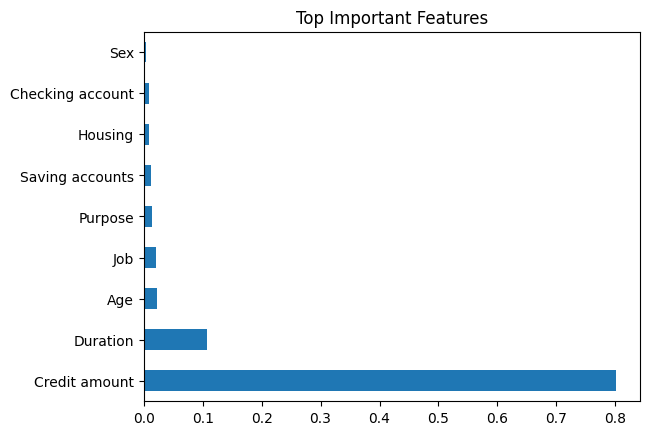

In [18]:
importances = rf.feature_importances_

feat_imp = pd.Series(importances, index=X.columns)
feat_imp.nlargest(10).plot(kind="barh")

plt.title("Top Important Features")
plt.show()


In [19]:
print(classification_report(y_test, y_pred_rf))


              precision    recall  f1-score   support

        High       1.00      1.00      1.00        14
         Low       1.00      1.00      1.00       130
      Medium       1.00      1.00      1.00        56

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



In [20]:
print("""
Observations:
- Random Forest performs best due to ensemble learning.
- Boosting improves prediction by reducing bias.
- Credit amount strongly influences risk classification.
- Cross-validation ensures stable performance.
""")



Observations:
- Random Forest performs best due to ensemble learning.
- Boosting improves prediction by reducing bias.
- Credit amount strongly influences risk classification.
- Cross-validation ensures stable performance.



In [ ]:
-